# Interesting Cases with Null Values in SDV

This cookbook explores specific scenarios you may encounter when synthesizing data with missing values. Each section is self-contained — jump to whichever case is relevant to you.

**Prerequisite:** Familiarity with SDV's basic null handling. If you're new to generating synthetic data from datasets with nulls, start with the *How to Generate Synthetic Data When Your Data Has Null Values* cookbook.

## Setup

We'll load a demo dataset and fit a default synthesizer that we can reference throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sdv.datasets.demo import download_demo
from sdv.single_table import GaussianCopulaSynthesizer
from rdt.transformers.pii import AnonymizedFaker
from rdt.transformers.numerical import FloatFormatter
from rdt.transformers.datetime import UnixTimestampEncoder

data, metadata = download_demo(
    modality='single_table',
    dataset_name='null_values_demo_dataset'
)

def phone_transformer():
    return {'customer_phone': AnonymizedFaker(
        provider_name='phone_number', function_name='phone_number'
    )}

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.auto_assign_transformers(data)
synthesizer.update_transformers(phone_transformer())
synthesizer.fit(data)
synthetic_data = synthesizer.sample(num_rows=2000)

print(f'Dataset: {data.shape[0]} rows, {data.shape[1]} columns')
print(f'Columns with nulls: {data.isnull().any().sum()}')

Dataset: 2000 rows, 17 columns
Columns with nulls: 13


## How different synthesizers handle null values

SDV offers several single-table synthesizers: `GaussianCopulaSynthesizer`, `CTGANSynthesizer`, `TVAESynthesizer`, and `CopulaGANSynthesizer`. Since null handling happens in the preprocessing layer — before the data reaches the synthesizer — all of them share a common preprocessing pipeline for null handling.

Let's verify by comparing GaussianCopula and CTGAN on our dataset:

In [2]:
from sdv.single_table import CTGANSynthesizer

ctgan = CTGANSynthesizer(metadata, epochs=5)
ctgan.auto_assign_transformers(data)
ctgan.update_transformers(phone_transformer())
ctgan.fit(data)
ctgan_synthetic = ctgan.sample(num_rows=2000)

null_compare = pd.DataFrame({
    'Real': data.isnull().mean().round(3),
    'GaussianCopula': synthetic_data.isnull().mean().round(3),
    'CTGAN': ctgan_synthetic.isnull().mean().round(3),
})
null_compare[null_compare['Real'] > 0]

,Real,GaussianCopula,CTGAN
customer_email,0.101,0.101,0.101
category,0.146,0.132,0.187
is_escalated,0.200,0.206,0.248
response_time_hours,0.049,0.044,0.044
resolution_time_hours,0.305,0.306,0.306
satisfaction_score,0.684,0.664,0.664
internal_notes_count,0.928,0.925,0.925
resolved_at,0.305,0.314,0.314
resolution_status,0.305,0.294,0.249
agent_name,0.078,0.078,0.078


The null rates are nearly identical across both synthesizers. The small differences come from the synthesizers' modeling approaches, not from how nulls are managed.

> **Key takeaway:** Your choice of synthesizer doesn't affect null handling. Pick the synthesizer based on your quality and performance needs.

## When null rates don't match: `from_column` distortion

When you use `missing_value_generation='from_column'`, the synthesizer needs to model a binary indicator — "is this value null or not?" — alongside all other columns. The `GaussianCopulaSynthesizer` models everything using continuous Gaussian distributions, which creates a fundamental mismatch: it's trying to represent a 0/1 signal with a bell curve. The result is that the synthesizer can produce null rates that are very different from the original data.

**How significant can the distortion be?**

In [3]:
nullable_numerical = [
    'response_time_hours', 'resolution_time_hours', 'satisfaction_score',
    'internal_notes_count', 'num_reassignments', 'response_time_legacy'
]

fc_synthesizer = GaussianCopulaSynthesizer(metadata)
fc_synthesizer.auto_assign_transformers(data)
fc_synthesizer.update_transformers(phone_transformer())
fc_synthesizer.update_transformers({
    col: FloatFormatter(missing_value_replacement='mean', missing_value_generation='from_column')
    for col in nullable_numerical
})
fc_synthesizer.update_transformers({
    'resolved_at': UnixTimestampEncoder(missing_value_generation='from_column'),
})
fc_synthesizer.fit(data)
synthetic_fc = fc_synthesizer.sample(num_rows=2000)

In [4]:
compare_cols = ['response_time_hours', 'resolution_time_hours', 'satisfaction_score',
                'internal_notes_count', 'num_reassignments']

for col in compare_cols:
    real_rate = data[col].isnull().mean()
    random_rate = synthetic_data[col].isnull().mean()
    fc_rate = synthetic_fc[col].isnull().mean()
    print(f'{col}:')
    print(f'  Real null rate:     {real_rate:.1%}')
    print(f'  random (default):   {random_rate:.1%}  (diff: {random_rate - real_rate:+.1%})')
    print(f'  from_column:        {fc_rate:.1%}  (diff: {fc_rate - real_rate:+.1%})')
    print()

response_time_hours:
  Real null rate:     4.9%
  random (default):   4.5%  (diff: -0.5%)
  from_column:        100.0%  (diff: +95.1%)

resolution_time_hours:
  Real null rate:     30.5%
  random (default):   30.6%  (diff: +0.2%)
  from_column:        31.6%  (diff: +1.1%)

satisfaction_score:
  Real null rate:     68.4%
  random (default):   66.4%  (diff: -2.0%)
  from_column:        67.8%  (diff: -0.7%)

internal_notes_count:
  Real null rate:     92.8%
  random (default):   92.5%  (diff: -0.2%)
  from_column:        99.0%  (diff: +6.2%)

num_reassignments:
  Real null rate:     19.5%
  random (default):   19.2%  (diff: -0.3%)
  from_column:        19.6%  (diff: +0.1%)



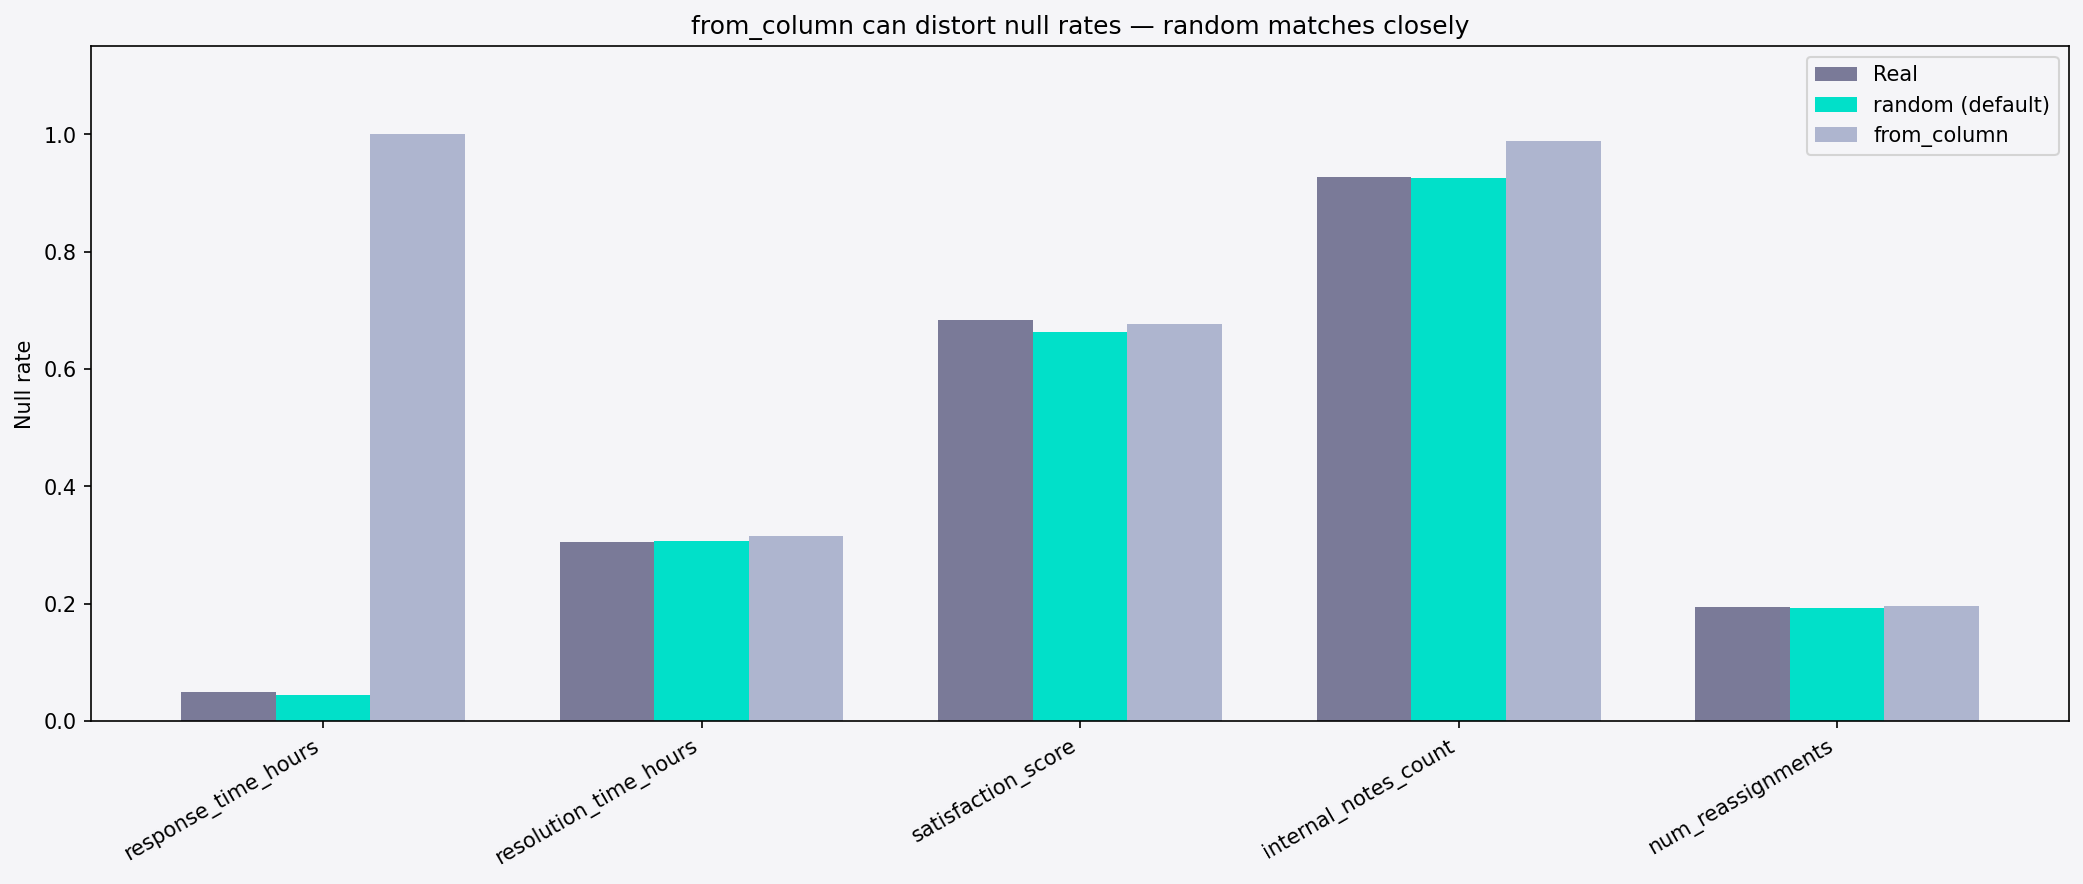

The `response_time_hours` column is the most dramatic example: it jumps from 4.9% null in the real data to 100% null with `'from_column'`. Meanwhile, the default `'random'` mode stays within 1% of the real rate.

The severity of the distortion depends on the original null rate. Columns near 50% null tend to be modeled more accurately, while columns at the extremes (very few nulls or very many) are most susceptible.

> **Key takeaway:** If you use `'from_column'` with GaussianCopula, always compare `data.isnull().mean()` against `synthetic_data.isnull().mean()` after sampling.

## How mean replacement affects synthetic data quality

Before the synthesizer trains, null values need to be replaced with actual numbers. The default strategy is `missing_value_replacement='mean'` — every null is filled with the column's mean value.

For columns with low null rates this barely matters. But for columns with high null rates, a significant portion of the training data becomes identical values clustered at the mean. The synthesizer then learns this artificial spike as a real pattern.

**What does this look like?**

In [5]:
col = 'response_time_hours'
mean_val = data[col].mean(skipna=True)

print(f'Column: {col}')
print(f'Null count: {data[col].isnull().sum()}')
print(f'Mean value: {mean_val:.2f}')
print()
print(f'With {data[col].isnull().mean():.1%} nulls, the effect is small here.')
print(f'But for satisfaction_score ({data["satisfaction_score"].isnull().mean():.1%} null),')
print(f'{data["satisfaction_score"].isnull().sum()} of {len(data)} training values would cluster at the mean.')

Column: response_time_hours
Null count: 98
Mean value: 4.07

With 4.9% nulls, the effect is small here.
But for satisfaction_score (68.4% null),
1368 of 2000 training values would cluster at the mean.


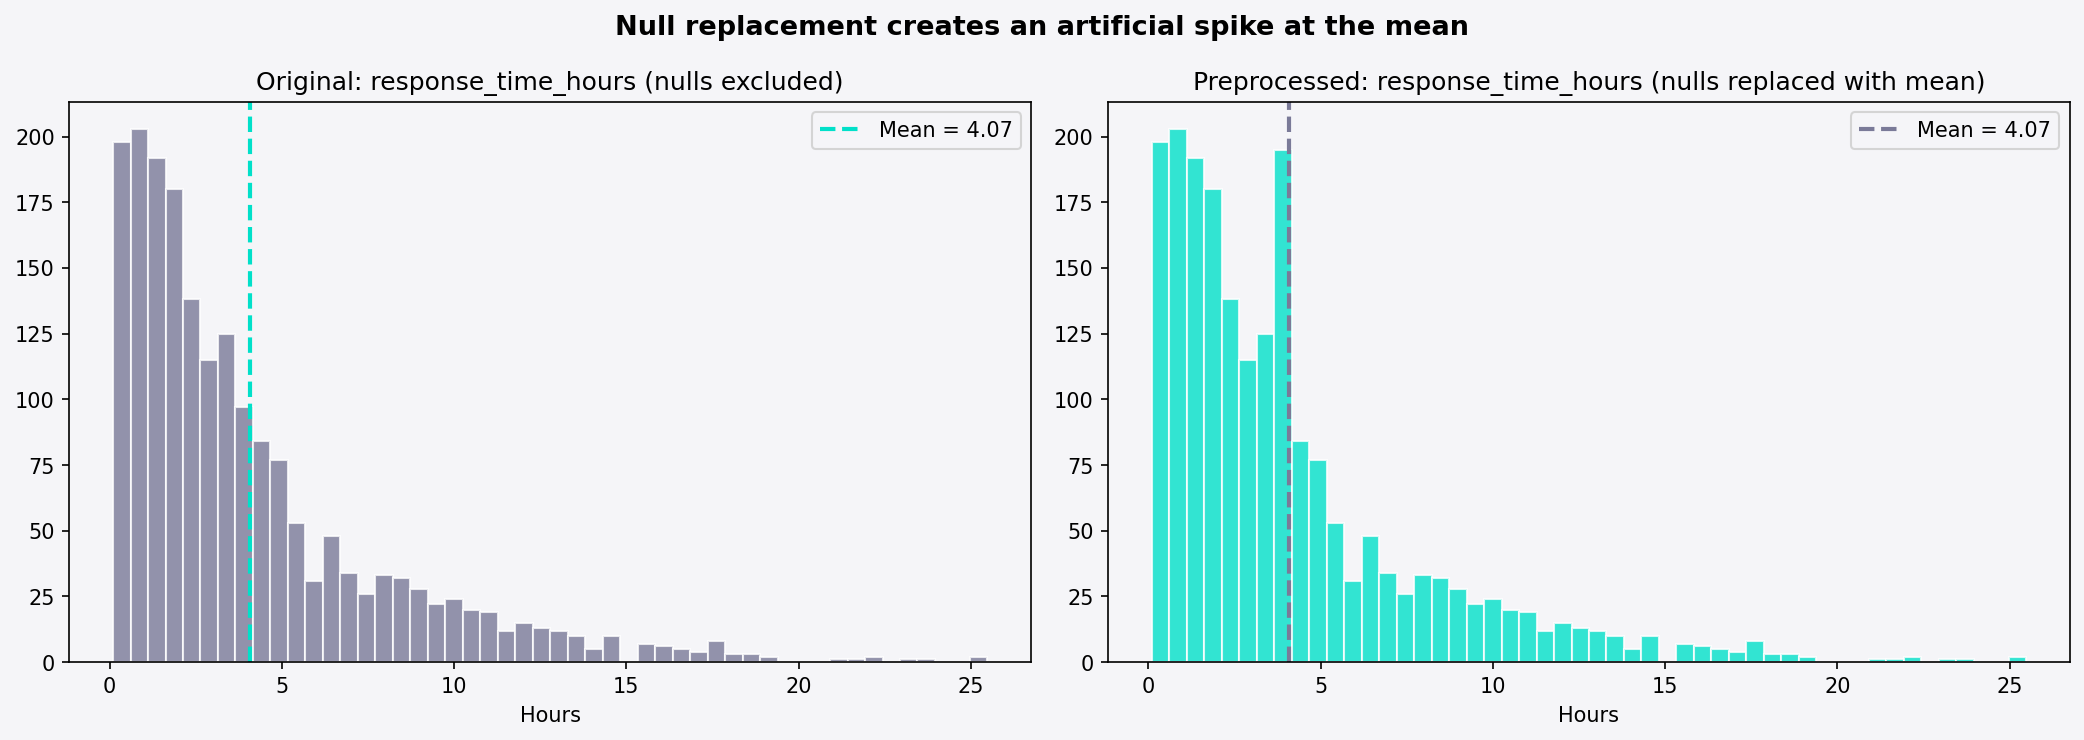

The alternative is `missing_value_replacement='random'`, which fills nulls with a value chosen uniformly at random from the column's min/max range:

```python
FloatFormatter(missing_value_replacement='random', missing_value_generation='random')
```

This avoids the artificial spike and generally produces better results for columns with many nulls.

## What `None` mode does (and doesn't do) across column types

Setting `missing_value_generation=None` tells SDV not to recreate nulls for a given column. This works well for numerical and datetime columns — the synthetic output will have zero missing values. But not all column types respect this setting equally.

**Which columns still have nulls after using `None` mode?**

In [6]:
none_synth = GaussianCopulaSynthesizer(metadata)
none_synth.auto_assign_transformers(data)
none_synth.update_transformers(phone_transformer())
none_synth.update_transformers({
    col: FloatFormatter(missing_value_replacement='mean', missing_value_generation=None)
    for col in ['response_time_hours', 'resolution_time_hours', 'satisfaction_score',
                'internal_notes_count', 'num_reassignments', 'response_time_legacy']
})
none_synth.update_transformers({
    'resolved_at': UnixTimestampEncoder(missing_value_generation=None),
})
none_synth.fit(data)
synthetic_none = none_synth.sample(num_rows=2000)

none_comparison = pd.DataFrame({
    'Real': data.isnull().mean().round(3),
    'None mode': synthetic_none.isnull().mean().round(3),
})
none_comparison[none_comparison['Real'] > 0]

,Real,None mode
customer_email,0.101,0.101
category,0.146,0.132
is_escalated,0.200,0.206
response_time_hours,0.049,0.000
resolution_time_hours,0.305,0.000
satisfaction_score,0.684,0.000
internal_notes_count,0.928,0.000
resolved_at,0.305,0.000
resolution_status,0.305,0.294
agent_name,0.078,0.078


Several columns still show nulls despite `None` mode:

- **Categorical columns** (`category`, `is_escalated`, `resolution_status`) — treat null as just another category value, so null is part of their learned distribution regardless
- **PII columns** (`customer_email`, `agent_name`, `customer_phone`) — regenerate values using Faker and independently reintroduce nulls at the original rate
- **All-null columns** (`customer_notes`) — there's nothing to generate, so the column stays 100% null

> **Key takeaway:** `None` mode works for numerical and datetime columns but does not affect categorical, PII, or all-null columns. To get zero nulls across all columns, clean your source data before fitting.

## Columns that are entirely null

The `customer_notes` column in our dataset is 100% null — every single value is missing. What does SDV do with a column that contains no actual data?

**What happens when a column is 100% null?**

In [7]:
print(f'customer_notes null rate (real): {data["customer_notes"].isnull().mean():.0%}')
print(f'customer_notes null rate (synthetic): {synthetic_data["customer_notes"].isnull().mean():.0%}')
print(f'Unique non-null values: {data["customer_notes"].nunique()}')

customer_notes null rate (real): 100%
customer_notes null rate (synthetic): 100%
Unique non-null values: 0


SDV handles this correctly — the synthetic output is also 100% null. Since null is the only known "category," everything maps back to null in the synthetic data.

This is expected behavior, but it means the synthesizer is doing unnecessary work. If you don't need the column in your synthetic output, consider dropping it from the data before fitting.

## Preserving nullable integer types (`Int64`)

When a pandas integer column contains null values, pandas automatically converts it to `float64` — because the standard `int64` type can't represent `NaN`. This means values display as `1.0` instead of `1`, and nulls appear as `NaN` instead of `<NA>`.

Pandas offers a nullable integer type, `Int64` (with a capital I), that avoids this conversion. SDV can work with `Int64`, but it requires three steps to round-trip correctly.

**Can SDV preserve `Int64`?**

In [8]:
# Step 1: See the default behavior (float64 with NaN)
print(f'Before — dtype: {data["num_reassignments"].dtype}')
print(data[['ticket_id', 'num_reassignments']].head(10))

Before — dtype: float64
   ticket_id  num_reassignments
0  TKT-00000                1.0
1  TKT-00001                3.0
2  TKT-00002                0.0
3  TKT-00003                2.0
4  TKT-00004                1.0
5  TKT-00005                3.0
6  TKT-00006                2.0
7  TKT-00007                NaN
8  TKT-00008                3.0
9  TKT-00009                5.0


In [9]:
# Step 2: Cast to Int64 and update metadata
data['num_reassignments'] = data['num_reassignments'].astype('Int64')

from sdv.metadata import Metadata
int64_meta = metadata.to_dict()
table_name = list(int64_meta['tables'].keys())[0]
int64_meta['tables'][table_name]['columns']['num_reassignments']['computer_representation'] = 'Int64'
int64_meta = Metadata.load_from_dict(int64_meta)

# Step 3: Re-fit and sample
int64_synth = GaussianCopulaSynthesizer(int64_meta)
int64_synth.auto_assign_transformers(data)
int64_synth.update_transformers(phone_transformer())
int64_synth.fit(data)
int64_result = int64_synth.sample(num_rows=500)

print(f'After — dtype: {int64_result["num_reassignments"].dtype}')
print(int64_result[['ticket_id', 'num_reassignments']].head(10))

After — dtype: Int64
   ticket_id  num_reassignments
0  TKT-00122                  5
1  TKT-00163                  5
2  TKT-00310                  3
3  TKT-00006                  2
4  TKT-00382                  4
5  TKT-00312                  5
6  TKT-00239                  3
7  TKT-00069                  4
8  TKT-00212               <NA>
9  TKT-00157               <NA>


To preserve nullable integers, you need all three steps: (1) cast the source column to `Int64`, (2) set `computer_representation='Int64'` in the metadata, and (3) re-fit the synthesizer. Without all three, integers degrade to `float64`.

This matters if downstream systems expect integer types or if you're comparing data schemas between real and synthetic data.

## Conclusion

These edge cases are good to know about but are rarely blockers. SDV's default null handling works well for most datasets — the `'random'` mode preserves null rates accurately and requires no configuration.

When something unexpected happens with nulls in your synthetic data, check back here: whether it's `from_column` distorting rates, `None` mode not applying to all column types, or integer columns losing their dtype, the fix is usually a small configuration change.